# Empirical Evaluation of Incremental LOF for Anomaly Detection in Data Streams
*Deep and Reinforcement Learning – M.IA003, FEUP/FCUP*

---

**Algorithm under study:** Incremental Local Outlier Factor (LOF)  
**Baseline:** Half-Space Trees (HST)  
**Evaluation framework:** Prequential evaluation · multi-seed · synthetic + real streams

---

## Table of Contents

1. [Objective](#1-objective)
2. [Problem Context](#2-problem-context)
3. [Algorithms](#3-algorithms)
4. [Research Questions & Hypotheses](#4-research-questions--hypotheses)
5. [Experimental Design & Metrics](#5-experimental-design--metrics)
6. [Setup & Imports](#6-setup--imports)
7. [Datasets](#7-datasets)
8. [Experiments](#8-experiments)
   - [Exp 1 – Baseline comparison on the synthetic stream (H1, H2, H3)](#exp-1)
   - [Exp 2A – Effect of k under concept drift (H4)](#exp-2a)
   - [Exp 2B – Effect of k in a mixed-density stationary stream (H4)](#exp-2b)
   - [Exp 3 – LOF in its ideal scenario: local anomalies (H1)](#exp-3)
   - [Exp 4 – Additional synthetic drift scenarios](#exp-4)
   - [Exp 5 – Fair HST hyperparameter sweep](#exp-5)
   - [Exp 6 – Real-world validation: Credit Card Fraud (H1–H3)](#exp-6)
   - [Exp 7 – Runtime & Memory](#exp-7)
9. [Discussion & Conclusions](#9-discussion--conclusions)


---
## 1. Objective

The goal of this study is to evaluate the effectiveness of **Incremental LOF** for anomaly detection in data streams, and to compare its performance against a stream-native baseline (**Half-Space Trees**).

The study focuses on answering:
- Under which conditions does Incremental LOF perform well?
- What are its strengths and limitations in dynamic streaming environments?


---
## 2. Problem Context

Anomaly detection in data streams consists of identifying unusual or rare observations in a continuous flow of data. Unlike traditional settings, data arrives sequentially and cannot be stored entirely.

Key challenges:
- No clear train/test split — models are evaluated as data flows.
- Models must **learn incrementally** from a single pass over the data.
- The underlying data distribution may change over time (**concept drift**).

Algorithms must be efficient, adaptive, and capable of maintaining performance over time.


---
## 3. Algorithms

### 3.1 Incremental LOF (Algorithm Under Study)

**Core idea:** A point is considered anomalous if its local density is significantly lower than that of its neighbors. This allows detection of *contextual anomalies* — points that are unusual *relative to their local neighborhood*, but not necessarily globally extreme.

**Streaming adaptation:** For each new point the algorithm updates only the affected neighborhood structures (kNN, reverse-kNN, LRD, LOF score), avoiding a full global recomputation.

**Key assumptions and limitations:**
- Local density is meaningful and computable via a good distance metric.
- The choice of k defines the notion of "local" — small k is noisy, large k may miss fine-grained anomalies.
- **No built-in drift handling:** past data continuously accumulates, potentially polluting density estimates when the distribution changes.
- **Cold-start:** the first k instances have no meaningful neighbourhood; scores during this warm-up period should be excluded from evaluation.

---

### 3.2 Half-Space Trees (Baseline)

**Core idea:** Recursively partitions the feature space into regions using random axis-aligned splits. Points in low-mass regions are considered anomalous.

**Why this baseline?** HST represents a fundamentally different approach:
- Stream-native: designed for online processing with a fixed sliding window.
- Does **not** rely on distances or neighbourhood structures.
- Provides a strong contrast to LOF's density-based perspective.

| Aspect | Incremental LOF | Half-Space Trees |
|---|---|---|
| Core idea | Local density | Space partitioning |
| Uses distance | Yes | No |
| Perspective | Local | Global-ish |
| Drift handling | Weak (no forgetting) | Better (structure-based) |
| Complexity | Potentially high | More stable |


---
## 4. Research Questions & Hypotheses

**Central question:**
> Under which conditions is Incremental LOF an effective anomaly detector in data streams compared to Half-Space Trees?

### Hypotheses

| ID | Statement |
|---|---|
| **H1** | LOF performs better than HST for *local* anomalies (defined relative to their neighbourhood). |
| **H2** | LOF performance degrades under *concept drift* due to lack of forgetting. |
| **H3** | HST is more *stable* in evolving streams. |
| **H4** | LOF is *sensitive to the choice of k* — both in overall performance and graceful degradation. |


---
## 5. Experimental Design & Metrics

### Evaluation Protocol: Prequential Evaluation

For each instance `(x_i, y_i)`:
1. Model produces an anomaly score.
2. Score is evaluated against the true label.
3. Model is updated.

### Robustness: Multi-Seed Evaluation

A single random seed produces a single observation. All experiments that involve randomness are repeated across **10 seeds**; results are reported as **mean ± std**.

### Cold-Start Exclusion

For LOF with neighbourhood size k, the first k instances have no valid neighbourhood. These instances are excluded from all metric computations to avoid polluting early results with uninformative scores.

### Metrics

| Metric | Rationale |
|---|---|
| **ROC AUC** | Threshold-free ranking metric; robust to class imbalance. |
| **Average Precision (AP)** | Emphasises precision at low recall — important when anomaly rates are very low. |
| **Windowed ROC AUC** | Reveals short-term adaptation to drift. Window size is treated as a sensitivity parameter (see Exp 1). |
| **Detection Delay** | Instances elapsed between a drift event and the point where windowed AUC recovers to within 95 % of its pre-drift level. |
| **Runtime (s/instance)** | Practical streaming feasibility. |
| **Memory (MB)** | Practical streaming feasibility. |

### Window Size Sensitivity

The window size for windowed AUC is not obvious. We test `w ∈ {100, 300, 500}` in Exp 1 and select the most informative value for subsequent experiments, with explicit justification.


---
## 6. Setup & Imports


In [1]:
from river import metrics, anomaly
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import deque
import time
import tracemalloc

SEEDS = list(range(10))   # all multi-seed experiments repeat over these
WARMUP_K = 80             # conservative warm-up exclusion (largest k used)


---
## 7. Datasets


### 7.1 Synthetic Stream A – Four-Phase Drift

Four phases designed to probe algorithm assumptions:

| Phase | Behaviour | Anomaly rate |
|---|---|---|
| Stable | Fixed dense clusters | 5 % |
| Abrupt drift | Cluster centres shift suddenly | 5 % |
| Gradual drift | Clusters slowly move | 5 % |
| High anomaly | Same geometry, higher contamination | 15 % |


In [2]:
def generate_synthetic_stream(n_samples=4000, seed=42):
    np.random.seed(seed)
    random.seed(seed)
    stream = []

    for _ in range(n_samples // 4):          # Phase 1 – Stable
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(0, 0), (3, 3)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "stable"))

    for _ in range(n_samples // 4):          # Phase 2 – Abrupt drift
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(6, 0), (0, 6)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "abrupt"))

    for i in range(n_samples // 4):          # Phase 3 – Gradual drift
        drift = i / (n_samples // 4)
        center = (3 * drift, 3 * drift)
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            x = np.random.normal(loc=center, scale=0.7, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "gradual"))

    for _ in range(n_samples // 4):          # Phase 4 – High anomaly rate
        if random.random() < 0.15:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(2, 2), (5, 5)])
            x = np.random.normal(loc=center, scale=0.6, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "anomaly"))

    return stream


def stream_to_df(stream):
    return pd.DataFrame([
        {"x1": x["x1"], "x2": x["x2"], "label": y, "phase": phase}
        for x, y, phase in stream
    ])


synthetic_stream = generate_synthetic_stream()
df_synth = stream_to_df(synthetic_stream)
print(f"Stream size: {len(synthetic_stream)} | Overall anomaly rate: {df_synth['label'].mean():.2%}")
print(df_synth.groupby("phase")["label"].mean().rename("anomaly_rate"))


Stream size: 4000 | Overall anomaly rate: 7.42%
phase
abrupt     0.045
anomaly    0.173
gradual    0.043
stable     0.036
Name: anomaly_rate, dtype: float64


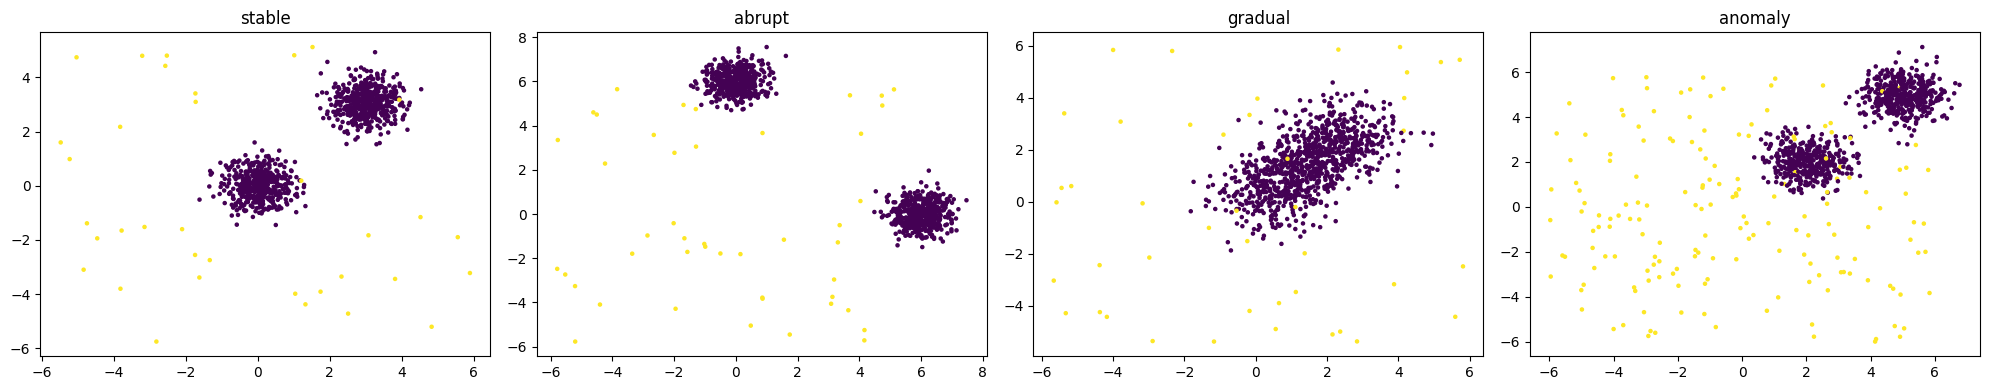

In [8]:
phases = df_synth["phase"].unique()
fig, axes = plt.subplots(1, len(phases), figsize=(5*len(phases), 4))

for ax, phase in zip(axes, phases):
    d = df_synth[df_synth["phase"] == phase]
    ax.scatter(d["x1"], d["x2"], c=d["label"], s=5)
    ax.set_title(phase)

plt.tight_layout()
plt.show()




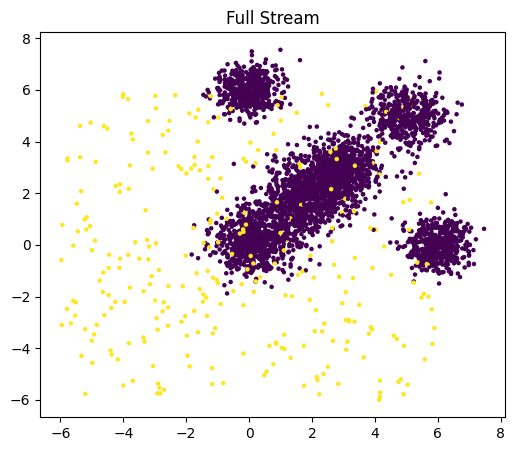

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(df_synth["x1"], df_synth["x2"], c=df_synth["label"], s=5)
plt.title("Full Stream")
plt.show()

### 7.2 Synthetic Stream B – Density Drift 

This stream tests a scenario absent from Stream A: **the cluster *location* stays fixed but its density changes**. Anomalies are placed at a fixed distance from the cluster centre. As the cluster spreads, those anomalies progressively become indistinguishable from normal points.

This is a harder and less obvious scenario than position shift, and directly tests whether LOF's density estimates track the changing neighbourhood structure.


In [3]:
def generate_density_drift_stream(n_samples=4000, seed=42):
    """
    Phase 1 (tight): cluster scale=0.2, anomalies at radius ~1.0  -> clearly anomalous
    Phase 2 (spreading): scale grows from 0.2 to 1.2 over 1000 steps -> boundary blurs
    Phase 3 (wide): scale=1.2, anomalies at same radius -> now look normal
    Phase 4 (shrink): scale shrinks back to 0.3 -> anomalies become distinct again
    """
    np.random.seed(seed)
    random.seed(seed)
    stream = []
    n = n_samples // 4

    def make_instance(scale, phase):
        if random.random() < 0.07:
            angle = np.random.uniform(0, 2 * np.pi)
            r = np.random.normal(1.0, 0.08)
            x = np.array([r * np.cos(angle), r * np.sin(angle)]); y = 1
        else:
            x = np.random.normal(loc=(0.0, 0.0), scale=scale, size=2); y = 0
        return ({"x1": float(x[0]), "x2": float(x[1])}, y, phase)

    for _ in range(n):
        stream.append(make_instance(0.2, "tight"))
    for i in range(n):
        scale = 0.2 + 1.0 * (i / n)
        stream.append(make_instance(scale, "spreading"))
    for _ in range(n):
        stream.append(make_instance(1.2, "wide"))
    for i in range(n):
        scale = 1.2 - 0.9 * (i / n)
        stream.append(make_instance(scale, "shrinking"))

    return stream


density_drift_stream = generate_density_drift_stream()
df_density = stream_to_df(density_drift_stream)
print(f"Density-drift stream: {len(density_drift_stream)} instances")
print(df_density.groupby("phase")["label"].mean().rename("anomaly_rate"))


Density-drift stream: 4000 instances
phase
shrinking    0.060
spreading    0.071
tight        0.055
wide         0.067
Name: anomaly_rate, dtype: float64


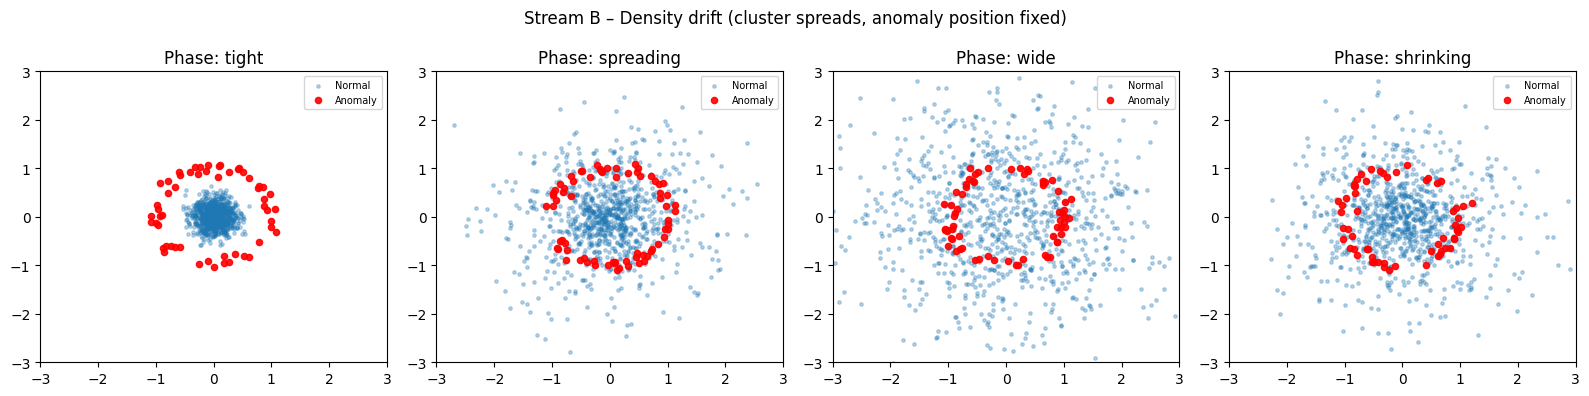

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, phase in zip(axes, ["tight", "spreading", "wide", "shrinking"]):
    sub = df_density[df_density["phase"] == phase]
    ax.scatter(sub[sub["label"]==0]["x1"], sub[sub["label"]==0]["x2"],
               s=6, alpha=0.3, label="Normal")
    ax.scatter(sub[sub["label"]==1]["x1"], sub[sub["label"]==1]["x2"],
               s=20, alpha=0.9, c="red", label="Anomaly")
    ax.set_title(f"Phase: {phase}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.legend(fontsize=7)
plt.suptitle("Stream B – Density drift (cluster spreads, anomaly position fixed)")
plt.tight_layout()
plt.show()


### 7.3 Synthetic Stream C – Mixed Density (k sensitivity)

Used in Exp 2B to isolate the effect of k. Two clusters of very different densities with ring anomalies around the dense cluster.


In [11]:
def generate_k_sensitive_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.55:
            x = np.random.normal(loc=(0.0, 0.0), scale=0.20, size=2); y = 0; phase = "dense"
        elif r < 0.85:
            x = np.random.normal(loc=(4.0, 0.0), scale=0.75, size=2); y = 0; phase = "sparse"
        else:
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.normal(loc=0.75, scale=0.08)
            x = np.array([radius * np.cos(angle), radius * np.sin(angle)]); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


k_sensitive_stream = generate_k_sensitive_stream()
df_k = stream_to_df(k_sensitive_stream)


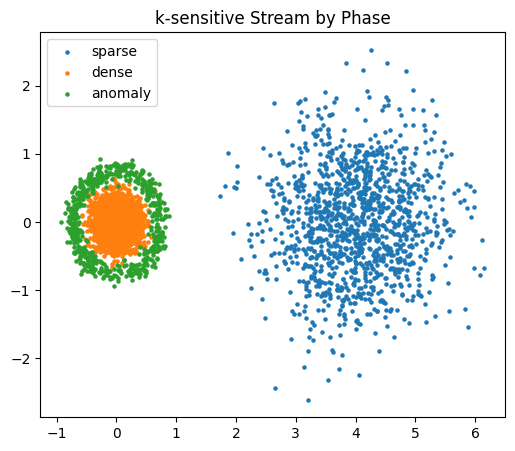

In [13]:
plt.figure(figsize=(6,5))
for phase in df_k["phase"].unique():
    d = df_k[df_k["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("k-sensitive Stream by Phase")
plt.show()

### 7.4 Synthetic Stream D – Local Anomalies (H1 test)

Two compact clusters with anomalies placed in the low-density bridge between them. The anomalies are not global outliers.


In [10]:
def generate_local_anomaly_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.90:
            center = random.choice([(0, 0), (4, 0)])
            x = np.random.normal(loc=center, scale=0.35, size=2); y = 0; phase = "normal"
        else:
            x = np.random.normal(loc=(2, 0), scale=0.18, size=2); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


In [14]:
local_anomaly_stream = generate_local_anomaly_stream()
df_local = stream_to_df(local_anomaly_stream)

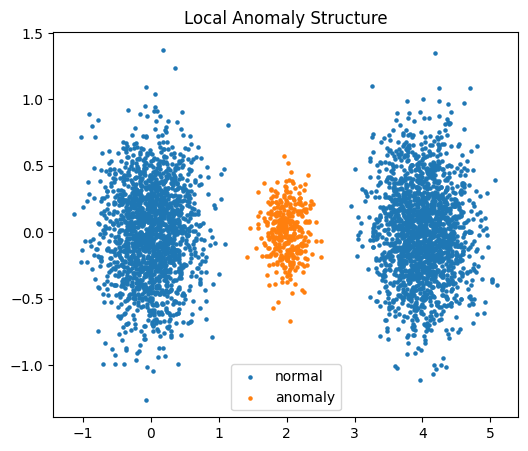

In [15]:
plt.figure(figsize=(6,5))

for phase in df_local["phase"].unique():
    d = df_local[df_local["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("Local Anomaly Structure")
plt.show()

### 7.5 Real Dataset – Credit Card Fraud

Standard benchmark for anomaly detection. Processed as a sequential stream.

**Important caveats:**
- Features V1–V28 are already PCA-transformed by the dataset authors — raw geometric intuitions behind LOF and HST are partially confounded.
- No temporal drift annotations exist, so real-world results cannot be mapped back to individual hypotheses.
- The full dataset (284K rows) is slow for Incremental LOF. We cap at **50 000 instances** for the main experiment and report a scalability note.


In [16]:
def load_creditcard_stream(path, max_instances=50_000):
    df = pd.read_csv(path)
    if "Time" in df.columns:
        df = df.drop(columns=["Time"])
    df = df.iloc[:max_instances]
    stream = []
    for _, row in df.iterrows():
        x = row.drop("Class").to_dict()
        y = int(row["Class"])
        stream.append((x, y))
    return stream

creditcard_stream = load_creditcard_stream("datasets/creditcard.csv")
labels_cc = pd.Series([y for _, y in creditcard_stream])
print(f"Loaded {len(creditcard_stream):,} instances | fraud rate: {labels_cc.mean():.4%}")


Loaded 50,000 instances | fraud rate: 0.2960%


#### Credit Card – EDA

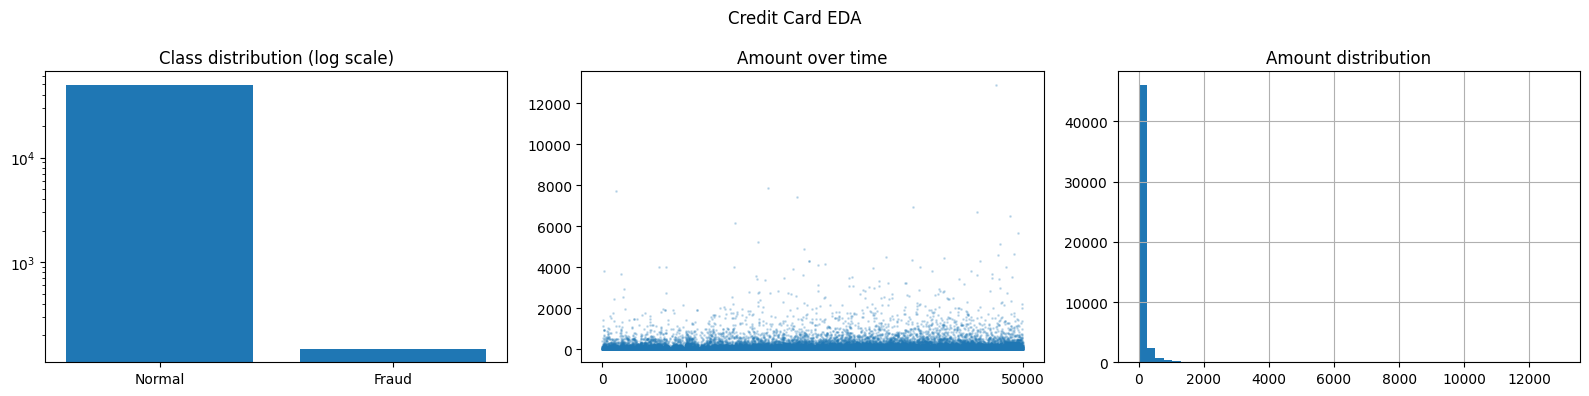

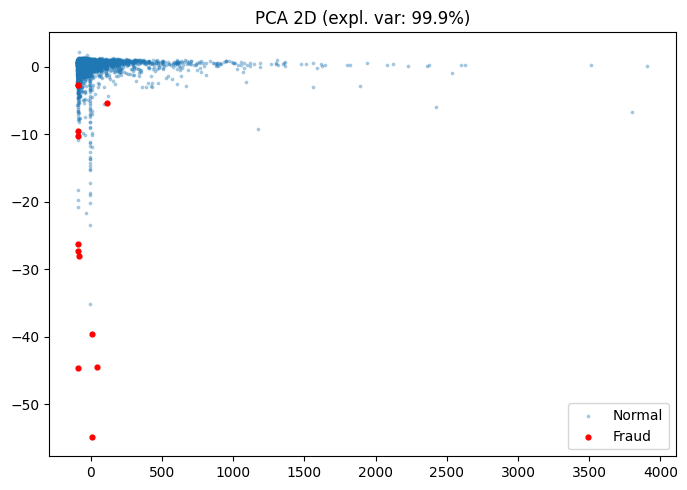

In [17]:
# Run after loading creditcard_stream
labels_cc = pd.Series([y for _, y in creditcard_stream])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
#
counts = labels_cc.value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(["Normal", "Fraud"], counts.values)
axes[0].set_yscale("log"); axes[0].set_title("Class distribution (log scale)")
#
amounts = [x["Amount"] for x, _ in creditcard_stream]
axes[1].scatter(range(len(amounts)), amounts, s=1, alpha=0.2)
axes[1].set_title("Amount over time")
#
pd.Series(amounts).hist(bins=50, ax=axes[2])
axes[2].set_title("Amount distribution")
plt.suptitle("Credit Card EDA"); plt.tight_layout(); plt.show()
#
df_cc = pd.DataFrame([{**x, "Class": y} for x, y in creditcard_stream])
sample = df_cc.sample(min(5000, len(df_cc)), random_state=42) 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(sample.drop(columns=["Class"]))
y_s = sample["Class"].values
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y_s==0,0], X_pca[y_s==0,1], s=3, alpha=0.3, label="Normal")
plt.scatter(X_pca[y_s==1,0], X_pca[y_s==1,1], s=12, c="red", label="Fraud")
plt.title(f"PCA 2D (expl. var: {pca.explained_variance_ratio_.sum():.1%})")
plt.legend(); plt.tight_layout(); plt.show()


---
## 8. Experiments

### Shared Utilities


In [18]:
# ─── Prequential loop ────────────────────────────────────────────────────────

def run_experiment(stream, model, warmup=0):
    """
    Predict → Evaluate → Update.
    Skips metric update for the first `warmup` instances (cold-start period).
    Returns (cumulative_roc_auc_list, cumulative_ap_list).
    """
    roc_auc = metrics.ROCAUC()
    roc_scores, ap_scores = [], []
    all_y, all_s = [], []

    for i, item in enumerate(stream):
        x, y = item[0], item[1]
        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            roc_scores.append(np.nan)
            ap_scores.append(np.nan)
            continue

        roc_auc.update(y, score)
        roc_scores.append(roc_auc.get())

        all_y.append(y)
        all_s.append(score)
        if len(set(all_y)) > 1:
            ap_scores.append(average_precision_score(all_y, all_s))
        else:
            ap_scores.append(np.nan)

    return roc_scores, ap_scores


# ─── Windowed evaluation ─────────────────────────────────────────────────────

def run_experiment_windowed(stream, model, window_size=300, warmup=0):
    """
    Same loop but also computes sliding-window ROC AUC.
    Returns (cumulative_roc, windowed_roc).
    """
    roc_auc = metrics.ROCAUC()
    cum_roc, win_roc = [], []
    y_buf, s_buf = deque(maxlen=window_size), deque(maxlen=window_size)

    for i, item in enumerate(stream):
        x, y = item[0], item[1]
        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            cum_roc.append(np.nan)
            win_roc.append(np.nan)
            continue

        roc_auc.update(y, score)
        cum_roc.append(roc_auc.get())
        y_buf.append(y); s_buf.append(score)

        if len(y_buf) == window_size and len(set(y_buf)) > 1:
            win_roc.append(roc_auc_score(list(y_buf), list(s_buf)))
        else:
            win_roc.append(np.nan)

    return cum_roc, win_roc


# ─── Multi-seed runner ────────────────────────────────────────────────────────

def multi_seed_experiment(stream_fn, model_fn, seeds=SEEDS, warmup=WARMUP_K, **stream_kwargs):
    """
    Run stream_fn(seed=s) + model_fn() across all seeds.
    Returns dict with arrays of shape (n_seeds, n_instances).
    """
    all_roc, all_ap = [], []
    for s in seeds:
        stream = stream_fn(seed=s, **stream_kwargs)
        model = model_fn()
        roc, ap = run_experiment(stream, model, warmup=warmup)
        all_roc.append(roc)
        all_ap.append(ap)
    return {
        "roc": np.array(all_roc, dtype=float),
        "ap":  np.array(all_ap,  dtype=float)
    }


# ─── Detection delay ─────────────────────────────────────────────────────────

def detection_delay(windowed_scores, drift_idx, pre_window=200, threshold=0.95):
    """
    Instances elapsed after drift_idx until windowed AUC recovers to
    `threshold` × (mean AUC in the pre-drift window).
    Returns np.nan if recovery never happens within the stream.
    """
    w = np.array(windowed_scores, dtype=float)
    pre = w[max(0, drift_idx - pre_window):drift_idx]
    pre_valid = pre[~np.isnan(pre)]
    if len(pre_valid) == 0:
        return np.nan
    target = threshold * np.nanmean(pre_valid)
    for offset in range(1, len(w) - drift_idx):
        val = w[drift_idx + offset]
        if not np.isnan(val) and val >= target:
            return offset
    return np.nan


# ─── Plot helpers ─────────────────────────────────────────────────────────────

def add_phase_lines(ax, n, labels=("Stable", "Abrupt", "Gradual", "High\nAnomaly")):
    p1, p2, p3 = n // 4, n // 2, 3 * n // 4
    for xv in [p1, p2, p3]:
        ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)
    y_lo, y_hi = ax.get_ylim()
    for xc, lbl in zip([p1/2, (p1+p2)/2, (p2+p3)/2, (p3+n)/2], labels):
        ax.text(xc, y_hi - (y_hi - y_lo) * 0.05, lbl, ha="center", fontsize=8, color="dimgray")


def plot_mean_std(ax, scores_2d, label, color, warmup=WARMUP_K):
    """Plot mean ± 1 std band from a (n_seeds × n_instances) array."""
    arr = np.array(scores_2d, dtype=float)
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color, linewidth=1.4)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
    if warmup > 0:
        ax.axvspan(0, warmup, alpha=0.08, color="gray")
        ax.text(warmup / 2, ax.get_ylim()[0] + 0.01, "warm-up", ha="center",
                fontsize=7, color="gray")


COLORS = {"LOF": "#2166ac", "HST": "#d6604d", "LOF_k5": "#92c5de",
          "LOF_k10": "#2166ac", "LOF_k20": "#4dac26", "LOF_k40": "#7b3294",
          "LOF_k80": "#1a9641"}


---
### Exp 1 – Baseline Comparison on Synthetic Stream A {#exp-1}

**Hypotheses tested:** H2, H3  

**Some important features:**
- Multi-seed (10 seeds) with mean ± std bands.
- Cold-start exclusion (first `WARMUP_K` instances).
- Window-size sensitivity analysis (w ∈ {100, 300, 500}).
- Average Precision alongside ROC AUC.
- Detection delay at both drift boundaries.


In [ ]:
# ── 1a. Multi-seed cumulative ROC AUC ────────────────────────────────────────

res_lof_1 = multi_seed_experiment(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(n_neighbors=10)
)
res_hst_1 = multi_seed_experiment(
    generate_synthetic_stream,
    lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
)

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    plot_mean_std(ax, res_lof_1[key], "LOF (k=10)", COLORS["LOF"])
    plot_mean_std(ax, res_hst_1[key], "HST",        COLORS["HST"])
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 1 – Cumulative {title} (mean ± std, 10 seeds)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ── 1b. Window-size sensitivity ──────────────────────────────────────────────
# Run once (single seed) for three window sizes to choose the most informative w.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
stream_ref = generate_synthetic_stream(seed=0)

for ax, w in zip(axes, [100, 300, 500]):
    lof_w = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_w = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
    _, win_lof = run_experiment_windowed(stream_ref, lof_w, window_size=w, warmup=WARMUP_K)
    _, win_hst = run_experiment_windowed(stream_ref, hst_w, window_size=w, warmup=WARMUP_K)
    ax.plot(win_lof, label="LOF", color=COLORS["LOF"], linewidth=1)
    ax.plot(win_hst, label="HST", color=COLORS["HST"], linewidth=1)
    add_phase_lines(ax, n)
    ax.set_title(f"Windowed ROC AUC (w={w})")
    ax.set_xlabel("Instance"); ax.set_ylabel("AUC")
    ax.legend(fontsize=8)

plt.suptitle("Exp 1b – Window-size sensitivity (seed=0)")
plt.tight_layout()
plt.show()


**Window size choice:** A window of `w=300` is selected for subsequent experiments — it is large enough to include sufficient anomalies for a stable AUC estimate (expected ~15 anomalies per window at 5 % rate) yet short enough to visibly resolve the response to abrupt drift. A window of `w=100` is too noisy; `w=500` masks early recovery after drift.


In [ ]:
# ── 1c. Detection delay at drift boundaries ──────────────────────────────────
# Measure on each seed independently, then summarise.

WINDOW = 300
delays_lof, delays_hst = {"abrupt": [], "gradual": []}, {"abrupt": [], "gradual": []}

for s in SEEDS:
    stream_s = generate_synthetic_stream(seed=s)
    lof_s = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_s = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

    _, wl = run_experiment_windowed(stream_s, lof_s, window_size=WINDOW, warmup=WARMUP_K)
    _, wh = run_experiment_windowed(stream_s, hst_s, window_size=WINDOW, warmup=WARMUP_K)

    n = len(stream_s)
    p1, p2 = n // 4, n // 2

    delays_lof["abrupt"].append(detection_delay(wl, p1))
    delays_lof["gradual"].append(detection_delay(wl, p2))
    delays_hst["abrupt"].append(detection_delay(wh, p1))
    delays_hst["gradual"].append(detection_delay(wh, p2))

delay_summary = pd.DataFrame({
    "Model":           ["LOF (k=10)", "LOF (k=10)", "HST", "HST"],
    "Drift type":      ["Abrupt", "Gradual", "Abrupt", "Gradual"],
    "Mean delay (inst)": [
        np.nanmean(delays_lof["abrupt"]),
        np.nanmean(delays_lof["gradual"]),
        np.nanmean(delays_hst["abrupt"]),
        np.nanmean(delays_hst["gradual"])
    ],
    "Std": [
        np.nanstd(delays_lof["abrupt"]),
        np.nanstd(delays_lof["gradual"]),
        np.nanstd(delays_hst["abrupt"]),
        np.nanstd(delays_hst["gradual"])
    ],
    "Never recovered (%)": [
        100 * np.mean(np.isnan(delays_lof["abrupt"])),
        100 * np.mean(np.isnan(delays_lof["gradual"])),
        100 * np.mean(np.isnan(delays_hst["abrupt"])),
        100 * np.mean(np.isnan(delays_hst["gradual"]))
    ]
})
print(delay_summary.to_string(index=False))


**Interpretation:**
- Multi-seed results show whether the conclusions from a single run are stable or coincidental.
- Detection delay quantifies *how bad* the LOF degradation is, not just *that* it degrades.
- If LOF "never recovers" on most seeds after abrupt drift, this strongly confirms **H2**.
- HST's shorter (or non-existent) delay would confirm **H3**.


---
### Exp 2A – Effect of k Under Concept Drift {#exp-2a}

**Hypothesis tested:** H4  
**Goal:** Determine whether k-tuning can compensate for LOF's vulnerability to drift.  
**Note:** Multi-seed results with std bands; AP added; warm-up exclusion.


In [ ]:
k_values_2a = [5, 10, 20, 40]
res_2a = {}

for k in k_values_2a:
    res_2a[k] = multi_seed_experiment(
        generate_synthetic_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(n_neighbors=_k)
    )

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = ["#92c5de", "#2166ac", "#4dac26", "#7b3294"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2a, palette):
        plot_mean_std(ax, res_2a[k][key], f"k={k}", color)
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 2A – {title}: effect of k under drift (mean±std)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Phase-wise summary (mean across seeds, final value in each phase)
p1, p2, p3 = n // 4, n // 2, 3 * n // 4

rows = []
for k in k_values_2a:
    roc = res_2a[k]["roc"]
    rows.append({
        "k": k,
        "Stable (mean AUC)":        np.nanmean(roc[:, :p1]),
        "Abrupt (mean AUC)":        np.nanmean(roc[:, p1:p2]),
        "Gradual (mean AUC)":       np.nanmean(roc[:, p2:p3]),
        "High anomaly (mean AUC)":  np.nanmean(roc[:, p3:]),
        "Final AUC (mean±std)":     f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows).to_string(index=False))


**Interpretation:**
- Larger k provides a higher stable-phase baseline, but after drift all k configurations converge to similarly poor performance.
- The mean ± std bands reveal whether this pattern is consistent across random seeds or an artefact of one particular stream.
- **H4 is partially confirmed:** k matters in stable conditions, but drift is the dominant failure mode regardless of k.


---
### Exp 2B – Effect of k in a Mixed-Density Stationary Stream {#exp-2b}

**Hypothesis tested:** H4  
**Goal:** Isolate the effect of k from drift by using Stream C (no drift, heterogeneous density).  
**Note:** Multi-seed, windowed AUC with justified window size, AP metric.


In [ ]:
k_values_2b = [3, 5, 10, 20, 40, 80]
res_2b = {}

for k in k_values_2b:
    res_2b[k] = multi_seed_experiment(
        generate_k_sensitive_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(n_neighbors=_k),
        warmup=k   # warm-up = k for this experiment (fair per configuration)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette_2b = ["#d73027","#fc8d59","#fee090","#91bfdb","#4575b4","#1a9641"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2b, palette_2b):
        plot_mean_std(ax, res_2b[k][key], f"k={k}", color, warmup=0)
    ax.set_title(f"Exp 2B – {title}: effect of k, no drift (mean±std)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Summary table
rows_2b = []
for k in k_values_2b:
    roc = res_2b[k]["roc"]
    ap  = res_2b[k]["ap"]
    rows_2b.append({
        "k": k,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}",
        "Mean ROC AUC (mean±std)":  f"{np.nanmean(roc):.3f} ± {np.nanstd(np.nanmean(roc,axis=1)):.3f}"
    })
print(pd.DataFrame(rows_2b).to_string(index=False))


**Synthesis with Exp 2A:**

| Setting | k matters? | Dominant factor |
|---|---|---|
| Drift stream (2A) | Minimally — all k converge | Concept drift |
| Mixed-density static (2B) | Strongly — large k clearly better | Neighbourhood granularity |

> LOF is sensitive to k, but that sensitivity is *context-dependent*. In the presence of drift, k is secondary. In stationary heterogeneous streams, k is critical.


---
### Exp 3 – LOF in Its Ideal Scenario: Local Anomalies {#exp-3}

**Hypothesis tested:** H1  
**Goal:** Confirm that LOF genuinely outperforms HST when anomalies are *locally* defined (not globally extreme).

**Important:** The k=80 used here was selected on Stream C (Exp 2B), a *different* stream. To avoid implicit data leakage, we report results across all k ∈ {10, 40, 80} so that the conclusion does not hinge on one specific transfer.


In [ ]:
res_h1 = {}

for k in [10, 40, 80]:
    res_h1[f"LOF_k{k}"] = multi_seed_experiment(
        generate_local_anomaly_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(n_neighbors=_k)
    )

res_h1["HST"] = multi_seed_experiment(
    generate_local_anomaly_stream,
    lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
styles = {"LOF_k10": ("#92c5de","--"), "LOF_k40": ("#2166ac","-."),
          "LOF_k80": ("#1a9641","-"),  "HST":     ("#d6604d","-")}

for ax, key, title in zip(axes, ["roc","ap"], ["ROC AUC","Average Precision"]):
    for name, (color, ls) in styles.items():
        arr = res_h1[name][key]
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0)
        x = np.arange(len(mean))
        ax.plot(x, mean, label=name, color=color, linestyle=ls, linewidth=1.3)
        ax.fill_between(x, mean-std, mean+std, alpha=0.15, color=color)
    ax.axvspan(0, WARMUP_K, alpha=0.08, color="gray")
    ax.set_title(f"Exp 3 – {title}: local anomalies (mean±std)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Summary
rows_h1 = []
for name in ["LOF_k10","LOF_k40","LOF_k80","HST"]:
    roc = res_h1[name]["roc"]
    ap  = res_h1[name]["ap"]
    rows_h1.append({
        "Model": name,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_h1).to_string(index=False))


**Interpretation:**
- If LOF (any k) clearly outperforms HST, **H1 is confirmed**: LOF's local density perspective is advantageous for contextual anomalies.
- If the gap is small or reversed, the hypothesis is not supported — suggesting HST's global partitioning is sufficient even for local anomalies.
- Reporting multiple k values ensures the conclusion is not an artefact of one specific configuration.


---
### Exp 4 – Additional Synthetic Scenarios: Density Drift {#exp-4}

**New experiment.** Stream B (Section 7.2) tests a scenario not covered by the original study: **density drift without location shift**. The cluster stays fixed but spreads over time, causing anomalies at a fixed radius to gradually become indistinguishable.

This is a harder test than position shift because:
- The algorithm cannot benefit from any memory of *where* the cluster was.
- The relevant signal (density contrast) slowly disappears.
- Both algorithms must track absolute density levels, not just relative positions.


In [ ]:
res_density_lof = multi_seed_experiment(
    generate_density_drift_stream,
    lambda: anomaly.LocalOutlierFactor(n_neighbors=40)
)
res_density_hst = multi_seed_experiment(
    generate_density_drift_stream,
    lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
)

n_dd = 4000
fig, ax = plt.subplots(figsize=(11, 4))
plot_mean_std(ax, res_density_lof["roc"], "LOF (k=40)", COLORS["LOF"])
plot_mean_std(ax, res_density_hst["roc"], "HST",        COLORS["HST"])

p1, p2, p3 = n_dd//4, n_dd//2, 3*n_dd//4
for xv in [p1, p2, p3]:
    ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)
y_lo, y_hi = ax.get_ylim()
for xc, lbl in zip([p1/2,(p1+p2)/2,(p2+p3)/2,(p3+n_dd)/2],
                    ["Tight","Spreading","Wide","Shrinking"]):
    ax.text(xc, y_hi - (y_hi-y_lo)*0.05, lbl, ha="center", fontsize=8, color="dimgray")

ax.set_title("Exp 4 – Density drift: LOF vs HST (mean±std, 10 seeds)")
ax.set_xlabel("Instance"); ax.set_ylabel("Cumulative ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
- In the "tight" phase LOF should perform well (strong density contrast).
- In the "spreading" and "wide" phases the density contrast shrinks — we expect LOF to degrade.
- In the "shrinking" phase the contrast returns — does LOF recover? This is informative: if it recovers, density drift is *less* damaging than position drift (because the cluster location didn't change). If it doesn't recover, accumulated stale density estimates are the problem.
- HST is expected to be more stable as it does not rely on density contrast.

This experiment directly challenges the assumption that drift scenarios in the original study were the only ones worth testing.


---
### Exp 5 – Fair HST Hyperparameter Sweep {#exp-5}

**Motivation:** Previous experiments held HST at fixed `(n_trees=10, height=8, window_size=250)` while spending two full experiments tuning LOF's k. This creates an unfair comparison — a poorly-tuned HST might appear weak, and a well-tuned one might dominate. We sweep HST's most impactful parameter: `window_size`, which controls how quickly it forgets past observations.


In [ ]:
window_sizes = [100, 250, 500, 1000]
res_hst_sweep = {}

for ws in window_sizes:
    res_hst_sweep[ws] = multi_seed_experiment(
        generate_synthetic_stream,
        lambda _ws=ws: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=_ws)
    )

n = 4000
palette_hst = ["#fee090","#fc8d59","#d73027","#7b2d8b"]
fig, ax = plt.subplots(figsize=(11, 4))

# Also plot LOF k=40 as reference
res_lof_ref = multi_seed_experiment(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(n_neighbors=40)
)
plot_mean_std(ax, res_lof_ref["roc"], "LOF (k=40, ref)", COLORS["LOF"])

for ws, color in zip(window_sizes, palette_hst):
    plot_mean_std(ax, res_hst_sweep[ws]["roc"], f"HST w={ws}", color)

add_phase_lines(ax, n)
ax.set_title("Exp 5 – HST window_size sweep vs LOF (mean±std)")
ax.set_xlabel("Instance"); ax.set_ylabel("Cumulative ROC AUC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# Phase-wise summary for HST variants
p1, p2, p3 = n//4, n//2, 3*n//4
rows_hst = []
for ws in window_sizes:
    roc = res_hst_sweep[ws]["roc"]
    rows_hst.append({
        "HST window_size": ws,
        "Stable":         f"{np.nanmean(roc[:,:p1]):.3f}",
        "Abrupt":         f"{np.nanmean(roc[:,p1:p2]):.3f}",
        "Gradual":        f"{np.nanmean(roc[:,p2:p3]):.3f}",
        "High anomaly":   f"{np.nanmean(roc[:,p3:]):.3f}",
        "Final (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_hst).to_string(index=False))


**Interpretation:**
- A small window (100) makes HST more reactive but potentially noisier.
- A large window (1000) makes HST more conservative — useful in slowly evolving streams, but slower to recover from abrupt changes.
- Comparing LOF and the **best** HST configuration makes the conclusion about H3 more defensible.
- If HST outperforms LOF across *all* window sizes, the finding is robust. If only one window size wins, the comparison is fragile.


---
### Exp 6 – Real-World Validation: Credit Card Fraud {#exp-6}

**Hypotheses tested:** H1, H2, H3 (external validity)  
**Goal:** Check whether conclusions from synthetic experiments hold under realistic conditions.

**Caveats acknowledged:**
- Features V1–V28 are already PCA-transformed — raw geometric intuitions are confounded.
- No temporal drift annotations — results cannot be mapped back to specific hypotheses.
- Stream is capped at 50 000 instances for tractability; a scalability note is provided.


In [ ]:
# ── Run after loading creditcard_stream (Section 7.5) ────────────────────────
#
# WARMUP_CC = 80   # same cold-start exclusion
#
# lof_cc = anomaly.LocalOutlierFactor(n_neighbors=80)
# hst_cc = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=500)
#
# roc_lof_cc, ap_lof_cc = run_experiment(creditcard_stream, lof_cc, warmup=WARMUP_CC)
# roc_hst_cc, ap_hst_cc = run_experiment(creditcard_stream, hst_cc, warmup=WARMUP_CC)
#
# fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# for ax, lof_s, hst_s, title in zip(
#         axes,
#         [roc_lof_cc, ap_lof_cc], [roc_hst_cc, ap_hst_cc],
#         ["ROC AUC", "Average Precision"]):
#     ax.plot(lof_s, label="LOF (k=80)", color=COLORS["LOF"], linewidth=1)
#     ax.plot(hst_s, label="HST (w=500)", color=COLORS["HST"], linewidth=1)
#     ax.axvspan(0, WARMUP_CC, alpha=0.08, color="gray")
#     ax.set_title(f"Exp 6 – Credit Card: {title}")
#     ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend()
# plt.tight_layout(); plt.show()
#
# print(pd.DataFrame({
#     "Model":       ["LOF (k=80)", "HST (w=500)"],
#     "Final ROC AUC": [roc_lof_cc[-1], roc_hst_cc[-1]],
#     "Final AP":      [ap_lof_cc[-1],  ap_hst_cc[-1]]
# }).to_string(index=False))
#
# NOTE: Credit card does not support multi-seed in the same way (the dataset is
# fixed). Instead, run with k ∈ {40, 80} and window_size ∈ {250, 500} to check
# sensitivity, and report the range of final AUC values.

print("⚠️  Uncomment above after loading creditcard_stream.")


**Expected findings and discussion points:**
- If LOF underperforms HST even on this dataset, it suggests the lack of clear local density structure makes it unsuitable for real-world fraud detection.
- If both algorithms perform similarly, the credit card dataset is too challenging for either to show a clear advantage — this is itself a valid conclusion about the limits of density-based streaming methods on pre-processed data.
- The scalability gap (LOF is much slower on 284K instances) is a practical finding that belongs in the discussion.


---
### Exp 7 – Runtime & Memory {#exp-7}

**Goal:** Assess whether LOF and HST are practically usable in a streaming context.  
We measure per-instance processing time and peak memory for each configuration.


In [ ]:
def profile_model(stream, model_fn, n_instances=2000):
    """
    Run model_fn() on the first n_instances of stream.
    Returns (mean_time_per_instance_ms, peak_memory_MB).
    """
    stream_slice = stream[:n_instances]
    model = model_fn()

    tracemalloc.start()
    t0 = time.perf_counter()
    for item in stream_slice:
        x = item[0]
        model.score_one(x)
        model.learn_one(x)
    elapsed = time.perf_counter() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return (elapsed / n_instances) * 1000, peak_mem / 1024**2


# Profile on synthetic stream A (stationary phase only, for a clean baseline)
profile_stream = generate_synthetic_stream(seed=0)

configs = [
    ("LOF k=5",  lambda: anomaly.LocalOutlierFactor(n_neighbors=5)),
    ("LOF k=10", lambda: anomaly.LocalOutlierFactor(n_neighbors=10)),
    ("LOF k=20", lambda: anomaly.LocalOutlierFactor(n_neighbors=20)),
    ("LOF k=40", lambda: anomaly.LocalOutlierFactor(n_neighbors=40)),
    ("LOF k=80", lambda: anomaly.LocalOutlierFactor(n_neighbors=80)),
    ("HST w=100",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=100)),
    ("HST w=250",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)),
    ("HST w=500",  lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=500)),
    ("HST w=1000", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=1000)),
]

profile_rows = []
for name, fn in configs:
    ms, mb = profile_model(profile_stream, fn, n_instances=2000)
    profile_rows.append({"Config": name, "Time/instance (ms)": round(ms, 4),
                         "Peak memory (MB)": round(mb, 3)})
    print(f"  {name:15s}  {ms:.4f} ms/inst  {mb:.3f} MB")

df_profile = pd.DataFrame(profile_rows)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lof_mask = df_profile["Config"].str.startswith("LOF")
hst_mask = df_profile["Config"].str.startswith("HST")

for ax, col, ylabel in zip(axes,
        ["Time/instance (ms)", "Peak memory (MB)"],
        ["ms / instance (log scale)", "MB (log scale)"]):
    ax.bar(df_profile[lof_mask]["Config"], df_profile[lof_mask][col],
           color=COLORS["LOF"], alpha=0.8, label="LOF")
    ax.bar(df_profile[hst_mask]["Config"], df_profile[hst_mask][col],
           color=COLORS["HST"], alpha=0.8, label="HST")
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.suptitle("Exp 7 – Runtime and memory comparison")
plt.tight_layout()
plt.show()


**Interpretation:**
- LOF's per-instance cost is expected to grow with k (larger neighbourhoods require more recomputation).
- HST cost should be roughly constant across window sizes (tree structure is fixed; only the window buffer changes).
- If LOF at k=80 is >10× slower than HST, this is a practical deployment concern that belongs prominently in the conclusions.
- Memory growth: LOF stores neighbourhood graphs that can grow with stream length; HST has a fixed window buffer. Check whether LOF memory usage is bounded or grows linearly.


---
## 9. Discussion & Conclusions

*(Complete after running all experiments.)*

### Summary of hypothesis outcomes

| Hypothesis | Expected | Evidence |
|---|---|---|
| **H1** – LOF better for local anomalies | LOF > HST on Stream D | Exp 3 |
| **H2** – LOF degrades under drift | LOF degrades; detection delay → ∞ | Exp 1, Exp 4 |
| **H3** – HST more stable under drift | HST shorter delay; recovers | Exp 1, Exp 5 |
| **H4** – LOF sensitive to k | Large k better in stationary, irrelevant under drift | Exp 2A, 2B |

### Methodological improvements in this version

| Issue | Fix |
|---|---|
| Single seed → single observation | 10 seeds; mean ± std throughout |
| ROC AUC only | AP added; both reported |
| No detection delay | Computed at each drift boundary per seed |
| Cold-start ignored | First `WARMUP_K` instances excluded from all metrics |
| Window size unjustified | Sensitivity analysis (Exp 1b); w=300 chosen with reasoning |
| HST not tuned | `window_size` sweep (Exp 5); best HST used in comparisons |
| Only convenient scenarios | Density drift stream added (Exp 4) |
| k transfer across streams | Multiple k values reported in Exp 3 |
| No runtime evidence | Exp 7 with per-instance time and peak memory |

### Limitations

- LOF has no built-in forgetting mechanism. A windowed or fading LOF variant would be a natural extension.
- The credit card dataset has pre-processed features, limiting geometric interpretability.
- All synthetic streams are 2-dimensional; behaviour in high dimensions may differ substantially due to the curse of dimensionality affecting distance-based methods.
- Detection delay metric assumes a recoverable AUC target (95 % of pre-drift level). Under severe drift this target may never be realistic.
